In [33]:
trace_file = 'experiments_mock/Qwen-7B_constant_sharegpt_code:azure_code_23_3978:4500_anytime_0.0/slosserve-edf_auto_scaling_resch-all_chat-1.0_1.0_8_anytime_3.0_0.025.reqs.jsonl'
events_file = 'experiments_mock/Qwen-7B_constant_sharegpt_code:azure_code_23_3978:4500_anytime_0.0/slosserve-edf_auto_scaling_resch-all_chat-1.0_1.0_8_anytime_3.0_0.025.events.jsonl'

In [2]:
import json 

In [4]:
with open(trace_file, 'r') as f:
    reqs = json.load(f)

In [10]:
max_tpots = [max(req['tpot_laxities']) for req in reqs]

In [11]:
import matplotlib.pyplot as plt

In [24]:
sum(max_tpot < 0.1 for max_tpot in max_tpots) / len(max_tpots)

0.9386973180076629

In [20]:
req = next(req for req in reqs if max(req['tpot_laxities']) > 0)

In [28]:
idx = next(i for i, tpot_laxity in enumerate(req['tpot_laxities']) if tpot_laxity > 0)

[{'batch_id': 15689,
  'num_scheduled_tokens': 1,
  'elapsed': 0.0319361686706543,
  'timestamp': 51.18210082054138,
  'device_id': 0},
 {'batch_id': 15690,
  'num_scheduled_tokens': 1,
  'elapsed': 0.03203082084655762,
  'timestamp': 51.21413784027099,
  'device_id': 0},
 {'batch_id': 15691,
  'num_scheduled_tokens': 1,
  'elapsed': 0.05372285842895508,
  'timestamp': 51.26786737442016,
  'device_id': 0},
 {'batch_id': 15692,
  'num_scheduled_tokens': 1,
  'elapsed': 0.038843393325805664,
  'timestamp': 51.306717443466184,
  'device_id': 0},
 {'batch_id': 15693,
  'num_scheduled_tokens': 1,
  'elapsed': 0.06791377067565918,
  'timestamp': 51.37464027404785,
  'device_id': 0},
 {'batch_id': 15694,
  'num_scheduled_tokens': 1,
  'elapsed': 0.04254651069641113,
  'timestamp': 51.41719822883606,
  'device_id': 0},
 {'batch_id': 15695,
  'num_scheduled_tokens': 1,
  'elapsed': 0.0313258171081543,
  'timestamp': 51.44853262901306,
  'device_id': 0},
 {'batch_id': 15696,
  'num_scheduled_tok

In [34]:
with open(events_file, 'r') as f:
    events = json.load(f)

In [36]:
batches = [event for event in events if event['event_type'] == 'batch']

In [40]:
batch_ids = set(batch['batch_id'] for batch in req['schedules'][idx - 10:idx + 10])

In [ ]:
batches_subset = [batch for batch in batches if batch['batch_id'] in batch_ids]

[{'event_type': 'batch',
  'batch_id': 12986,
  'timestamp': 0.49892544746398926,
  'elapsed': 0.01516866683959961,
  'req_ids': ['1'],
  'num_computed_tokens': [0],
  'num_scheduled_tokens': {'1': 29},
  'scheduling_overhead': 0.0003323554992675781,
  'between_batch_time': 0.01516866683959961,
  'output_processing_elapsed': 1.71661376953125e-05,
  'estimated_time': 0,
  'device_id': 0},
 {'event_type': 'batch',
  'batch_id': 12987,
  'timestamp': 0.5204257965087891,
  'elapsed': 0.021492719650268555,
  'req_ids': ['5', '3', '1'],
  'num_computed_tokens': [0, 0, 29],
  'num_scheduled_tokens': {'1': 1, '5': 42, '3': 74},
  'scheduling_overhead': 0.0009329319000244141,
  'between_batch_time': 0.021492719650268555,
  'output_processing_elapsed': 1.7642974853515625e-05,
  'estimated_time': 0,
  'device_id': 0},
 {'event_type': 'batch',
  'batch_id': 12988,
  'timestamp': 0.5415668487548828,
  'elapsed': 0.021132946014404297,
  'req_ids': ['6', '2', '5', '3'],
  'num_computed_tokens': [0, 0

In [2]:
import json

In [ ]:
filename = 'experiments_mock/Qwen-7B_constant_azure_code_23:azure_code_23_0:1000_arrival_0.0/slosserve-edf_slosserve_1.0_6_arrival_5.0_0.05.events.jsonl'
req_filename = 'experiments_mock/Qwen-7B_constant_azure_code_23:azure_code_23_0:1000_arrival_0.0/slosserve-edf_slosserve_1.0_6_arrival_5.0_0.05.reqs.jsonl'
filename = 'experiments_mock/Qwen-7B_constant_azure_code_23:azure_code_23_0:1000_arrival_0.0/atfc_slosserve_1.0_6_arrival_5.0_0.05.events.jsonl'
req_filename = 'experiments_mock/Qwen-7B_constant_azure_code_23:azure_code_23_0:1000_arrival_0.0/atfc_slosserve_1.0_6_arrival_5.0_0.05.reqs.jsonl'
with open(filename, 'r') as f:
    data = json.load(f)
with open(req_filename, 'r') as f:
    req_data = json.load(f)

In [4]:
batches = [x for x in data if x['event_type'] == 'batch']

In [5]:
batches = [(b['between_batch_time'] - b['estimated_time'], b) for b in batches]

In [6]:
batches = sorted(batches, reverse = True, key = lambda x: x[0])

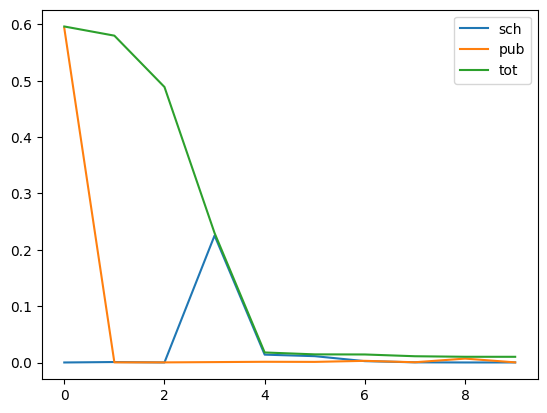

In [7]:
top_batches = batches[:10]
scheduling_overheads = [b[1]['scheduling_overhead'] for b in top_batches]
publish_overheads = [b[1]['publish_overhead'] for b in top_batches]
total_overhead = [b[0] for b in top_batches]
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
for label, overheads in [
    ('sch', scheduling_overheads),
    ('pub', publish_overheads),
    ('tot', total_overhead)
]:
    ax.plot(overheads, label = label)
ax.legend()

In [8]:
[x['event_type'] for x in req_data[0]['events']], req_data[0]['events'], req_data[0]['slo_violation']

(['global_arrival',
  'arrival-router',
  'router_decision',
  'dispatch',
  'arrival',
  'finish'],
 [{'event_type': 'global_arrival',
   'timestamp': 0.016457080841064453,
   'device_id': 0,
   'request_id': '0'},
  {'event_type': 'arrival-router',
   'timestamp': 0.387859582901001,
   'device_id': -1,
   'request_id': '0',
   'prefill_ddl': 0.5632791519165039,
   'profit': 1.0,
   'prompt_tokens': 217,
   'max_tokens': 9,
   'zero_load_ttft': 0.0250839},
  {'event_type': 'router_decision',
   'timestamp': 0.4014616012573242,
   'device_id': -1,
   'request_id': '0',
   'prefill_device_id': 0,
   'decode_device_id': 0},
  {'event_type': 'dispatch',
   'timestamp': 0.4088120460510254,
   'device_id': -1,
   'type': 'both',
   'request_id': '0',
   'prefill_device_id': 0,
   'decode_device_id': 0},
  {'event_type': 'arrival',
   'timestamp': 0.4146907329559326,
   'device_id': 0,
   'request_id': '0',
   'prompt_tokens': 217,
   'num_cached_tokens': 0,
   'max_tokens': 9,
   'prefill_d

In [9]:
req_data[0].keys()

dict_keys(['req_id', 'prompt_tokens', 'num_cached_tokens', 'arrival_time', 'engine_arrival_time', 'profit', 'schedules', 'events', 'timestamps', 'output_tokens', 'prefill_device_id', 'decode_device_id', 'cache_hit_rate', 'prefill_ddl', 'ttft_normalized_laxity', 'tpot_laxities', 'expected_finish_time', 'finish_reason', 'slo_violation', 'kv_xfer_delay', 'zero_load_ttft'])

In [10]:
from collections import defaultdict
import pandas as pd

In [33]:
slo_violated_to_arrive_finish_pairs = defaultdict(list)
slo_violated_to_finish_rescheduling_pairs = defaultdict(list)
slo_attained_to_arrive_finish_pairs = defaultdict(list)

In [34]:
violation_reasons = defaultdict(int)
for req in req_data:

    violation_reasons[req['slo_violation']] += 1
    for e, next_e in zip(req['events'], req['events'][1:]):
        if e['event_type'] == 'arrival':
            assert next_e['event_type'] == 'finish'
            if req['slo_violation'] != 'none':
                slo_violated_to_arrive_finish_pairs[req['req_id']].append((e['timestamp'], next_e['timestamp'], e['device_id']))
            else:
                slo_attained_to_arrive_finish_pairs[req['req_id']].append((e['timestamp'], next_e['timestamp'], e['device_id']))
        if e['event_type'] == 'finish' and next_e['event_type'] == 'rescheduling':
            slo_violated_to_finish_rescheduling_pairs[req['req_id']].append(next_e['timestamp'] - e['timestamp'])
violation_reasons

defaultdict(int, {'none': 904, 'ttft': 28, 'tpot': 3, 'router_rejection': 65})

In [55]:
rejected_reqs = [req for req in req_data if 'reject' in req['slo_violation']]
results = []
for req in rejected_reqs:
    breakdown = []
    acc = 0
    for e, next_e in zip(req['events'][1:], req['events'][2:]):
        gap = round(next_e['timestamp'] - e['timestamp'], 6)
        breakdown.append((e['event_type'] + '->' + next_e['event_type'], gap, acc + gap))
        acc += gap
    results.append((req['req_id'], req['prefill_ddl'] - req['arrival_time'], req['prompt_tokens'], breakdown))
results[0]
# TODO: visulize this for each request by having a bar graph, each entry is a request with a breakdown by time categories; also, add a mark for each request's req['prefill_ddl'] - req['arrival_time']

('84',
 0.7221395969390869,
 2361,
 [('arrival-router->router_decision', 0.00395, 0.00395),
  ('router_decision->dispatch', 0.003062, 0.007012000000000001),
  ('dispatch->arrival', 0.027223, 0.034235),
  ('arrival->finish', 0.69869, 0.732925),
  ('finish->rescheduling', 0.055351, 0.7882760000000001),
  ('rescheduling->finish', 0.001087, 0.789363)])

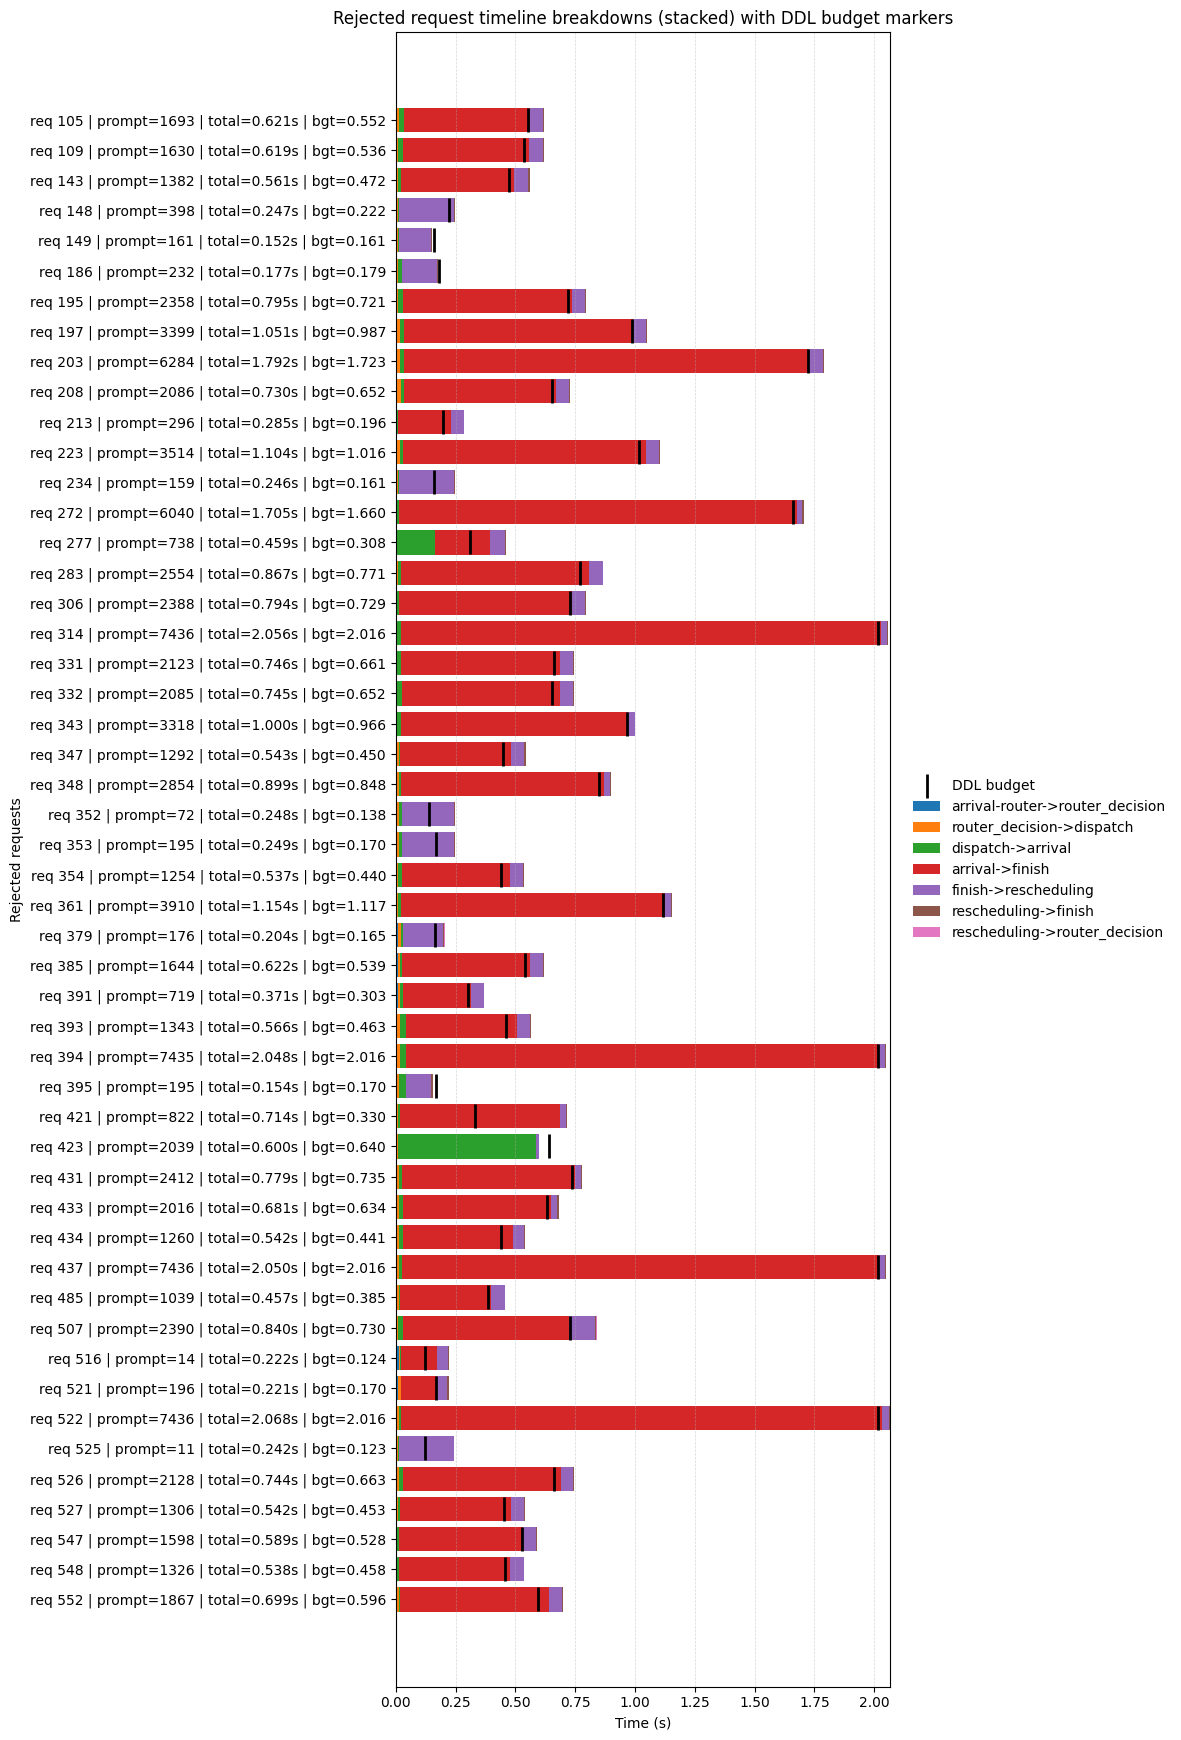

In [60]:
import matplotlib.pyplot as plt

def plot_reject_breakdowns(results, max_reqs=None, sort_by="ddl", title=None):
    """
    Stacked horizontal bars per request:
      - each segment = time gap between events
      - vertical marker = ddl_budget (prefill_ddl - arrival_time)

    sort_by: "ddl" | "total" | "prompt" | None
    """
    if not results:
        raise ValueError("results is empty")

    # Optionally sort
    if sort_by == "ddl":
        results = sorted(results, key=lambda x: x[0])
    elif sort_by == "total":
        results = sorted(results, key=lambda x: sum(seg[1] for seg in x[2]))
    elif sort_by == "prompt":
        results = sorted(results, key=lambda x: x[1])

    if max_reqs is not None:
        results = results[:max_reqs]

    # Build a stable category list (preserve first-seen order)
    categories = []
    cat_set = set()
    for req_id, ddl_budget, prompt_tokens, breakdown in results:
        for label, gap, _ in breakdown:
            if label not in cat_set:
                cat_set.add(label)
                categories.append(label)

    # Matrix of durations: rows=requests, cols=categories
    durations = []
    ddl_budgets = []
    prompts = []
    totals = []
    req_ids = []
    

    for req_id, ddl_budget, prompt_tokens, breakdown in results:
        row = {c: 0.0 for c in categories}
        total = 0.0
        for label, gap, _ in breakdown:
            row[label] += float(gap)
            total += float(gap)
        durations.append([row[c] for c in categories])
        ddl_budgets.append(float(ddl_budget))
        prompts.append(int(prompt_tokens))
        totals.append(total)
        req_ids.append(req_id)

    n = len(results)
    y = list(range(n))

    # Plot
    fig_h = max(4, 0.35 * n)  # scale height with number of reqs
    fig, ax = plt.subplots(figsize=(12, fig_h))

    left = [0.0] * n
    for j, cat in enumerate(categories):
        seg = [durations[i][j] for i in range(n)]
        ax.barh(y, seg, left=left, label=cat)
        left = [left[i] + seg[i] for i in range(n)]

    # DDL markers (one per request)
    # Using scatter with "|" marker makes it easy to see.
    ax.scatter(ddl_budgets, y, marker="|", s=300, color="black", linewidths=2, label="DDL budget")

    # Y labels: include prompt tokens + total
    ylabels = [f"req {req_ids[i]} | prompt={prompts[i]} | total={totals[i]:.3f}s | bgt={ddl_budgets[i]:.3f}" for i in range(n)]
    ax.set_yticks(y)
    ax.set_yticklabels(ylabels)

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Rejected requests")
    ax.invert_yaxis()  # top-to-bottom

    if title is None:
        title = "Rejected request timeline breakdowns (stacked) with DDL budget markers"
    ax.set_title(title)

    # Helpful grid
    ax.grid(True, axis="x", linestyle="--", linewidth=0.5, alpha=0.5)

    # Legend: put outside if many categories
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

    plt.tight_layout()
    return fig, ax

# Example usage:
fig, ax = plot_reject_breakdowns(results, max_reqs=50, sort_by="ddl")
plt.show()

(count    904.000000
 mean       1.016593
 std        0.136200
 min        1.000000
 25%        1.000000
 50%        1.000000
 75%        1.000000
 max        3.000000
 dtype: float64,
 count    96.000000
 mean      1.020833
 std       0.143576
 min       1.000000
 25%       1.000000
 50%       1.000000
 75%       1.000000
 max       2.000000
 dtype: float64)

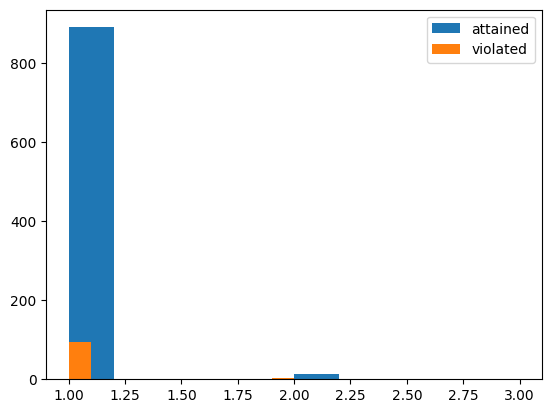

In [58]:
attained_lens = [len(x) for x in slo_attained_to_arrive_finish_pairs.values()]
violated_lens = [len(x) for x in slo_violated_to_arrive_finish_pairs.values()]
fig, ax = plt.subplots()
ax.hist(attained_lens, label = 'attained')
ax.hist(violated_lens, label = 'violated')
ax.legend()
pd.Series(attained_lens).describe(), pd.Series(violated_lens).describe()

In [14]:
trajectories = [[y[-1] for y in x] for x in slo_violated_to_arrive_finish_pairs.values()]
trajectories

[[0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [2],
 [0],
 [2],
 [0],
 [1],
 [0],
 [1],
 [0],
 [0],
 [0],
 [0],
 [2],
 [2],
 [3],
 [1],
 [0],
 [0],
 [1],
 [1],
 [2],
 [0],
 [0],
 [1],
 [1],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [1],
 [1, 3],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [2],
 [2],
 [2],
 [1],
 [1],
 [1],
 [0],
 [0],
 [1],
 [1],
 [1],
 [0, 3],
 [0],
 [0],
 [0],
 [0],
 [2],
 [2],
 [2],
 [2],
 [2],
 [2],
 [2],
 [2],
 [0],
 [0],
 [0],
 [0],
 [0],
 [1],
 [1],
 [1],
 [1],
 [3],
 [1],
 [1],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [1],
 [0],
 [1],
 [1],
 [1]]

(count    2.000000
 mean     0.120026
 std      0.127349
 min      0.029977
 25%      0.075002
 50%      0.120026
 75%      0.165051
 max      0.210076
 dtype: float64,
 (array([1., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
  array([0.02997684, 0.04798672, 0.0659966 , 0.08400648, 0.10201635,
         0.12002623, 0.13803611, 0.15604599, 0.17405586, 0.19206574,
         0.21007562]),
  <BarContainer object of 10 artists>))

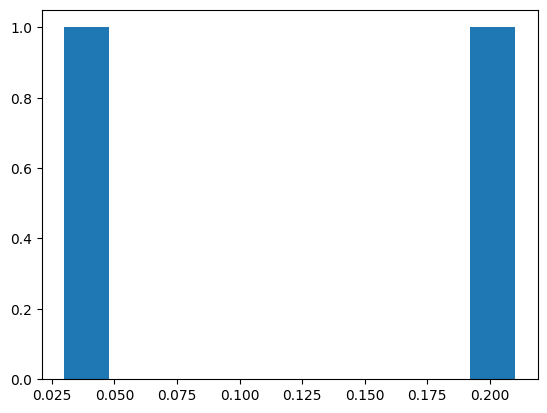

In [26]:
time_bewteen_arrives = []
for req, arrive_finish_pairs in slo_violated_to_arrive_finish_pairs.items():
    time_bewteen_arrives.extend(x[0] - y[0] for x, y in zip(arrive_finish_pairs[1:], arrive_finish_pairs))
pd.Series(time_bewteen_arrives).describe(), plt.hist(time_bewteen_arrives)

In [76]:
top_batches = batches[:10]

n_overlap = 0
for req, arrive_finish_pairs in slo_violated_to_arrive_finish_pairs.items():
    is_overlap = False
    for arrive, finish, device in arrive_finish_pairs:
        for _, b in top_batches:
            if (b['device_id'] == device) and (arrive < b['timestamp']) and (b['timestamp'] < finish):
                is_overlap = True 
    n_overlap += is_overlap
n_overlap / len(slo_violated_to_arrive_finish_pairs), n_overlap, len(slo_violated_to_arrive_finish_pairs)

(0.11458333333333333, 11, 96)

(count      96.000000
 mean     1522.052083
 std      1792.118977
 min        11.000000
 25%       191.500000
 50%      1130.000000
 75%      2124.250000
 max      7436.000000
 dtype: float64,
 count     904.000000
 mean     2259.162611
 std      2092.715037
 min        10.000000
 25%       697.500000
 50%      1637.000000
 75%      3010.250000
 max      7437.000000
 dtype: float64)

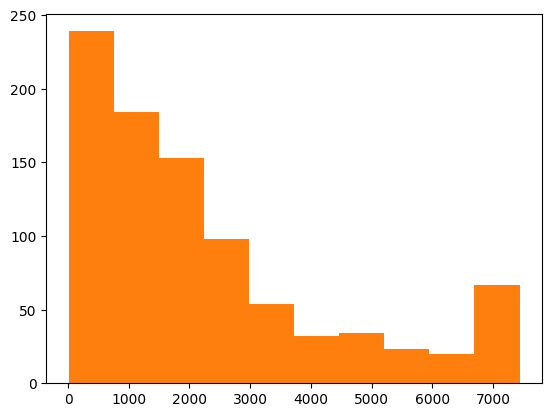

In [15]:
violated_reqs = [req for req in req_data if req['slo_violation'] != 'none']
attained_reqs = [req for req in req_data if req['slo_violation'] == 'none']
plt.hist([req['prompt_tokens'] for req in violated_reqs])
plt.hist([req['prompt_tokens'] for req in attained_reqs])
pd.Series([req['prompt_tokens'] for req in violated_reqs]).describe(), pd.Series([req['prompt_tokens'] for req in attained_reqs]).describe()

In [23]:
violated_reqs[5]

{'req_id': '89',
 'prompt_tokens': 204,
 'num_cached_tokens': 0,
 'arrival_time': 188.6897008419037,
 'engine_arrival_time': 188.7269208431244,
 'profit': 0,
 'schedules': [],
 'events': [{'event_type': 'global_arrival',
   'timestamp': 188.5438632965088,
   'device_id': 0,
   'request_id': '89'},
  {'event_type': 'arrival-router',
   'timestamp': 188.6897008419037,
   'device_id': -1,
   'request_id': '89',
   'prefill_ddl': 188.86180543899536,
   'profit': 1.0,
   'prompt_tokens': 204,
   'max_tokens': 63,
   'zero_load_ttft': 0.024420900000000002},
  {'event_type': 'router_decision',
   'timestamp': 188.69125866889954,
   'device_id': -1,
   'request_id': '89',
   'prefill_device_id': 0,
   'decode_device_id': 0},
  {'event_type': 'dispatch',
   'timestamp': 188.69679403305054,
   'device_id': -1,
   'type': 'both',
   'request_id': '89',
   'prefill_device_id': 0,
   'decode_device_id': 0},
  {'event_type': 'arrival',
   'timestamp': 188.7269208431244,
   'device_id': 0,
   'reques